In [1]:
import numpy as np
import random as rd
import matplotlib.pyplot as plt

In [2]:
#Vhevamos experimento de milica
#Hay que resolver laplace y asì, quiero simular el campo elèctrico en las placas (min 27)(modificaremos frontera exterior)
#Overlap, se empalman puntos para compartir memorìa y no se sature 

In [4]:
def M_Jac_iter(V,V0=1.0):
    Nx , Ny = V.shape
    for i in range(1,Nx-1):
        for j in range(1,Ny-1):
            if V[i,j] != 1:
                V[i,j] = 0.25*(V[i+1,j] + V[i-1,j] + V[i,j+1] + V[i,j-1])
    return V

def Met_Jac(V,V0=1,err=1e-3,step=20):
    diferencia = 1
    while diferencia > err:
        for i in range(step):
            V = M_Jac_iter(V,V0=V0)
        V_ref = M_Jac_iter(np.copy(V))
        diferencia = np.max(abs(V_ref-V))
    return V

def V_c_electrodos(x,y,electrodo_in,electrodo_out,V0=1): #Era v_front_cuad
    Nx , Ny = len(x) , len(y)
    malla = np.zeros((Nx,Ny))
    for i in range(1,Nx-1):
        for j in range(1,Ny-1):  #Este ciclo verifica si mu punto està dentro o fuera de mi figurita
            if  electrodo_in(x[i],y[j]) == True: #Caso donde està dentro
                malla[i,j] = 1 
            elif electrodo_out(x[i],y[j]) == True:
                malla[i,j] = 0
            else:
                malla[i,j] = rd.random()  #Si està fuera le coloco un color aleatorio  
    return V0*malla

def M_mouse(x,y):
    respuesta = False
    c1 = x**2 + y**2
    c2 , c3 = (x-0.9)**2 + (y-0.9)**2 , (x+0.9)**2 + (y-0.9)**2
    if c1 <= 1 or c2 <= 0.35 or c3 <= 0.35:
        respuesta = True
    return respuesta

def elipse(x,y):
    la_elipse = x**2/6+ y**2/4    
    respuesta = False
    if la_elipse<=1:
        repuesta = True
    return
    

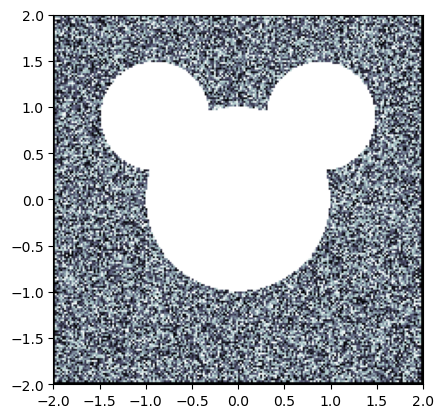

In [6]:
x , y = np.linspace(-2,2,200) , np.linspace(-2,2,200)
V = V_c_electrodos(x,y,M_mouse,elipse)
plt.imshow( V.transpose(),
           extent=(x[0],x[-1],y[0],y[-1]),
           origin='lower',
           cmap='bone' )
plt.show()
#Quiero saber el campo elèctrico entre el contorno y el mickie. Hay que modificar Jac_iter para que no relaje la frontera 
#y pueda graficar bien

In [ ]:
#Graficar en 3D, lo grafico ocomo superficie
XX, YY = np.meshgrid(x,y)
figura = plt.figure(figsize=(8,6), dpi=100)
ejes = figura.add_subplot(111, projection=3d)   #111 es pq tenemos sòlo 1 figura
ejes.view_init